# Differentiate through an intermediate file

In [1]:
import jax
import jax.numpy as jnp
import jax.export
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.style.use("ggplot")

In [2]:
x = jnp.array([1.0, 2.0, 3.0])  # data

def f_a(x, theta):
    return x * theta**3

def f_b(y):
    return jnp.sum(y)

pipeline = lambda theta: f_b(f_a(x, theta))  # full chain

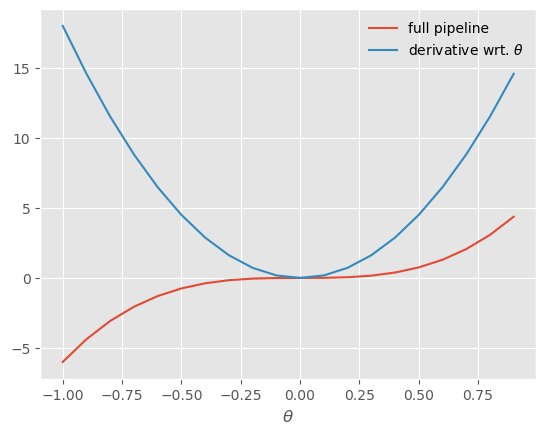

In [3]:
thetas = jnp.arange(-1, 1, 0.1)
fig, ax = plt.subplots()
ax.plot(thetas, jax.vmap(pipeline)(thetas), label="full pipeline")
ax.plot(thetas, jax.vmap(jax.grad(pipeline))(thetas), label=r"derivative wrt. $\theta$")
ax.set_xlabel(r"$\theta$")
_ = ax.legend(frameon=False)

Lets differentiate through the full pipeline for $\theta=0.5$.

In [4]:
theta = 0.5

# gradient through full pipeline
jax.grad(pipeline)(theta)

Array(4.5, dtype=float32, weak_type=True)

Here is a more manual and explicit version with VJPs:

In [5]:
theta = 0.5

# forward pass
y, vjp_a = jax.vjp(lambda theta: f_a(x, theta), theta)
z, vjp_b = jax.vjp(f_b, y)

# backward pass
v = jnp.array(1.0)
(dzdy,) = vjp_b(v)
(dz_dtheta,) = vjp_a(dzdy)

print(f"dz/dtheta at theta={theta} is {dz_dtheta}")

dz/dtheta at theta=0.5 is 4.5


## With an intermediate file

Now do the same with a pipeline that goes through an intermediate file.
For a pipeline $(x, \theta)$ -`f_a`-> $y$ -`f_b`-> $z$, we get $\frac{dz}{d\theta} = \frac{\partial z}{\partial y} \cdot \frac{\partial y}{\partial \theta}$.

In [6]:
def forward_and_save_vjp(name, db, f, primals):
    """Run f forward, save its output and vjp, register to database."""
    output, vjp_fn = jax.vjp(f, *primals)
    output_file = f"{name}_result.npz"
    np.savez(output_file, output=np.asarray(output))

    vjp_file = f"{name}_vjp.jax"
    with open(vjp_file, "wb") as f:
        f.write(jax.export.export(jax.jit(vjp_fn))(jnp.ones_like(output)).serialize())

    db[name] = {"output": output_file, "vjp": vjp_file}
    return output, db


def load_output(name, db):
    """Load output of a step."""
    return jnp.array(np.load(db[name]["output"])["output"])


def load_and_apply_vjp(name, db, cotangent):
    """Load vjp, apply to cotangent vector, save, register to database."""
    with open(db[name]["vjp"], "rb") as f:
        vjp_fn = jax.export.deserialize(f.read())

    result = vjp_fn.call(cotangent)
    cotangent_file = f"{name}_cotangent.npz"
    np.savez(cotangent_file, **{f"grad_{i}": np.asarray(g) for i, g in enumerate(result)})
    db[name]["cotangent"] = cotangent_file
    return result, db


def load_cotangent(name, db):
    """Load cotangent result of a backward step."""
    data = np.load(db[name]["cotangent"])
    return tuple(jnp.array(data[k]) for k in sorted(data.files))

### Forward pass
#### Step 1: Run `f_a` forward and save output and `vjp` to disk

In [7]:
db = {}  # "database" keeping track of files on disk

theta = 0.5
y, db = forward_and_save_vjp("f_a", db, lambda theta: f_a(x, theta), (theta,))
print(f"result of first step forward pass: {y}")

result of first step forward pass: [0.125 0.25  0.375]


#### Step 2: Run `f_b` forward and save output and `vjp` to disk

In [8]:
y_from_disk = load_output("f_a", db)
z, db = forward_and_save_vjp("f_b", db, f_b, (y_from_disk,))
print(f"result of second step forward pass: {z}")

result of second step forward pass: 0.75


### Backward pass

Take user-provided vector `v` and go through the VJPs in reverse.

#### Step 3: Load `vjp` for `f_b` and compute $v^T \cdot \frac{\partial z}{\partial y}$

In [9]:
v = jnp.array(1.0)

(dzdy,), db = load_and_apply_vjp("f_b", db, v)
print(f"v^T * dz/dy = {dzdy}")

v^T * dz/dy = [1. 1. 1.]


The shape here of `dzdy` exactly matches the shape of `y`, i.e. the output of `f_a` in the forward pass and the input to the backward pass of `f_a` match.
This is no coincidence but a general feature of the approach.
In practice this means that any kind of serialized exchange formats can re-use the same structure.
In an example where `f_a` produces a workspace, the exchange format of `f_b` -> `f_a` in the backward pass would be a "gradient" version of it with the same shape.

#### Step 4: Load `vjp` for `f_a` and compute $v^T \cdot \frac{dz}{d\theta} = (v^T \cdot \frac{\partial z}{\partial y}) \cdot \frac{\partial y}{\partial \theta}$

In [10]:
dzdy_from_disk, = load_cotangent("f_b", db)
(dz_dtheta,), db = load_and_apply_vjp("f_a", db, dzdy_from_disk)
print(f"dz/dtheta at theta={theta} is {dz_dtheta}")

dz/dtheta at theta=0.5 is 4.5
